# NLP03 — 한-영 Transformer 번역기 프로젝트

LMS **「더 멋진 번역기 만들기」** 프로젝트 제출용 노트북입니다.

- **한국어 → 영어** Seq2Seq Transformer (2-layer, Pre-LN)
- **SentencePiece** 토큰화 · 데이터 정제 · 학습 · 추론
- **Attention Map** 시각화 (루브릭 요구사항)

> Mac: MPS 자동 선택 · Python으로 데이터 다운로드 · `tqdm` 사용


In [1]:
# ================================================================================
# 🎯 [Step 0. 환경 초기화 및 전역 상수 정의]
# - 목적: 재현 가능한 실험 환경을 구축하고, 이후 모든 셀에서 공유할 경로·상수를 선언합니다.
# - 한-영 번역기는 Encoder(한국어) + Decoder(영어) 구조이므로, 여기서 정의한 상수가
#   데이터 필터링·임베딩 크기·학습 전반에 일관되게 사용됩니다.
# ================================================================================
import math
import platform
import random
import re
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm  # Mac/Jupyter 호환: tqdm.notebook 대신 tqdm 사용

# === 하이퍼파라미터 / 상수 ===
SEED = 42
# 난수 시드를 고정하면 매번 동일한 train/val 분리·가중치 초기화가 재현됩니다.

MAX_SEQ_LEN = 50
# 한 문장의 최대 토큰 수. LMS와 동일하게 50을 넘는 문장은 학습에서 제외합니다.
# 너무 긴 문장은 메모리·학습 시간이 급증하므로 상한을 둡니다.

SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000
# SentencePiece 어휘 크기. 한국어·영어 각각 2만 개의 subword 토큰을 학습합니다.
# 한-영은 언어가 다르므로 소스(ko)·타겟(en) 토크나이저를 별도로 만듭니다.

# 1. 파이썬·NumPy·PyTorch 난수 생성기를 동일 시드로 동기화
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. 연산 디바이스 자동 선택: Mac MPS → NVIDIA CUDA → CPU 순
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

# 3. Apple Silicon에서 float32 행렬 곱 속도·정밀도 조정 (PyTorch 2.x)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# 4. 데이터·체크포인트 저장 경로 (없으면 자동 생성)
DATA_DIR = Path("./data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = DATA_DIR / "best_ko_en_transformer.pt"
# 학습 중 train loss가 최저인 epoch의 가중치를 이 경로에 저장합니다.

# 5. Attention Map 한글 라벨용 matplotlib 폰트 설정
if platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")       # macOS
else:
    plt.rc("font", family="NanumBarunGothic")  # Linux 등

print("torch:", torch.__version__)
print("device:", device)
print("DATA_DIR:", DATA_DIR)


torch: 2.8.0
device: mps
DATA_DIR: /Users/choiseunghyeon/AIFFEL_Quest_ENG/04_NLP/NLP03/data


## Step 1. 데이터 다운로드

[jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora) 한-영 뉴스 말뭉치


In [2]:
# ================================================================================
# 🎯 [Step 1. 한-영 병렬 말뭉치 다운로드]
# - 출처: jungyeul/korean-parallel-corpora (한국어-영어 뉴스 말뭉치)
# - .ko / .en 파일이 한 줄씩 대응되는 병렬 코퍼스입니다.
# ================================================================================

def get_data_dir() -> Path:
    """
  [데이터 경로 탐색]
  노트북 실행 위치에 따라 data 폴더 위치가 달라질 수 있어,
  이미 다운로드된 말뭉치가 있는 경로를 우선 탐색합니다.
  """
    candidates = [
        Path.cwd() / "data",
        Path.cwd().parent / "NLP01" / "korean-english-park.train",
        Path.cwd() / "LMS" / "data",
        Path.home() / "pytorch-env" / "LMS" / "data",
        Path.home() / "pytorch-env" / "LMS" / "data" / "data",
        DATA_DIR,
    ]
    for c in candidates:
        if (c / "korean-english-park.train.ko").exists():
            return c.resolve()
    # 어디에도 없으면 현재 디렉터리 ./data 에 새로 받습니다.
    out = (Path.cwd() / "data").resolve()
    out.mkdir(parents=True, exist_ok=True)
    return out


DATA_DIR = get_data_dir()
url = (
    "https://github.com/jungyeul/korean-parallel-corpora/raw/master/"
    "korean-english-news-v1/korean-english-park.train.tar.gz"
)
archive = DATA_DIR / "korean-english-park.train.tar.gz"
ko_file = DATA_DIR / "korean-english-park.train.ko"
eng_file = DATA_DIR / "korean-english-park.train.en"

if ko_file.exists() and eng_file.exists():
    # 이미 압축 해제된 파일이 있으면 재다운로드 생략 (시간 절약)
    print("이미 존재:", ko_file.name, eng_file.name)
else:
    print("다운로드 중... (수백 MB, 수 분 소요)")
    urllib.request.urlretrieve(url, str(archive))
    with tarfile.open(str(archive), "r:*") as tar:
        tar.extractall(DATA_DIR)  # tar 안의 .ko, .en 파일을 DATA_DIR에 풀기
    print("완료")


이미 존재: korean-english-park.train.ko korean-english-park.train.en


## Step 2. 데이터 정제 및 토큰화

루브릭: **데이터 정제 · SentencePiece 토큰화 · 데이터셋 구축**


In [3]:
# ================================================================================
# 🎯 [Step 2-A. 데이터 정제 · SentencePiece 토큰화]
# - 루브릭 요구: 데이터 정제, SentencePiece 토큰화
# - 흐름: 원본 읽기 → 중복 제거 → 전처리 → ko/en 각각 SPM 학습
# ================================================================================

def clean_corpus(kor_path, eng_path):
    """
  [병렬 코퍼스 정제]
  - 한 줄씩 대응되는 ko/en 파일을 읽습니다.
  - set으로 중복 문장 쌍을 제거해 학습 노이즈·중복 연산을 줄입니다.
  - 반환: "한국어\\t영어" 형태의 문자열 리스트
  """
    with open(kor_path, encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, encoding="utf-8") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng), "한국어·영어 줄 수가 일치해야 병렬 코퍼스입니다."
    return list({f"{k}\t{e}" for k, e in zip(kor, eng)})


def preprocess_sentence(sentence: str) -> str:
    """
  [문장 전처리]
  - 소문자 변환 (영어 일관성)
  - 한글·영문·?.!, 만 남기고 나머지 제거
  - 구두점 앞뒤 공백 삽입 → 토큰 경계 명확화
  """
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    return sentence.strip()


def generate_tokenizer(corpus, vocab_size, lang="ko"):
    """
  [SentencePiece 토크나이저 학습]
  - corpus: 전처리된 문장 리스트
  - vocab_size: 서브워드 어휘 크기 (20,000)
  - pad=0, bos=1, eos=2, unk=3 은 Transformer 학습 관례 ID
  - 학습 결과: {lang}_spm.model, {lang}_spm.vocab 파일 생성
  """
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(str(row) + "\n")
    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        f"--input=./{file} --model_prefix={model} --vocab_size={vocab_size} "
        f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
    )
    tok = spm.SentencePieceProcessor()
    tok.Load(f"{model}.model")
    return tok


# --- 실제 정제·토큰화 실행 ---
kor_path = DATA_DIR / "korean-english-park.train.ko"
eng_path = DATA_DIR / "korean-english-park.train.en"
cleaned_corpus = clean_corpus(kor_path, eng_path)
print("cleaned_corpus:", len(cleaned_corpus))

kor_corpus, eng_corpus = [], []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

# 한국어·영어 각각 별도 SentencePiece 모델 학습
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
# 영어는 디코더 입력 시 <bos>...<eos> 를 자동으로 붙이도록 설정
en_tokenizer.set_encode_extra_options("bos:eos")
print("tokenizer 준비 완료")


cleaned_corpus: 78968


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

tokenizer 준비 완료


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././en_corpus.txt --model_prefix=en_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././en_corpus.txt
  input_format: 
  model_prefix: en_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

In [4]:
# ================================================================================
# 🎯 [Step 2-B. 데이터셋 구축 — 정수 인코딩 · 패딩 · GPU 텐서화]
# - 루브릭 요구: 데이터셋 구축
# - MAX_SEQ_LEN 초과 문장 제외 후, 가변 길이 시퀀스를 배치 가능한 텐서로 변환
# ================================================================================

src_corpus, tgt_corpus = [], []

for i in tqdm(range(len(kor_corpus)), desc="filter & encode"):
    # SentencePiece로 문장 → 정수 ID 리스트 변환
    src_ids = ko_tokenizer.encode_as_ids(kor_corpus[i])
    tgt_ids = en_tokenizer.encode_as_ids(eng_corpus[i])
    # 너무 긴 문장은 학습에서 제외 (메모리·속도·안정성)
    if len(src_ids) <= MAX_SEQ_LEN and len(tgt_ids) <= MAX_SEQ_LEN:
        src_corpus.append(torch.tensor(src_ids, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_ids, dtype=torch.long))


def pad_sequences(sequences, padding_value=0):
    """
  [패딩]
  - 배치 내 문장마다 길이가 다르므로, 짧은 문장 끝에 pad_id(0)를 채워
    [batch_size, max_len] 형태의 직사각형 텐서로 만듭니다.
  """
    return torch.nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=padding_value
    )


# enc_train: Encoder 입력 (한국어), dec_train: Decoder 정답 (영어, bos/eos 포함)
enc_train = pad_sequences(src_corpus).to(device)
dec_train = pad_sequences(tgt_corpus).to(device)
print("enc_train:", enc_train.shape, "| dec_train:", dec_train.shape)
# shape 예: torch.Size([72000, 50]) → 약 7만 문장, 최대 길이 50


filter & encode: 100%|██████████| 78968/78968 [00:03<00:00, 23180.84it/s]


enc_train: torch.Size([72107, 50]) | dec_train: torch.Size([72107, 50])


## Step 3. Transformer 모델 정의 (Pre-LN + final_norm)


In [5]:
# ================================================================================
# 🎯 [Step 3. Transformer 모델 정의]
# - 구조: Pre-LayerNorm + final_norm (LMS 프로젝트와 동일)
# - Encoder: 한국어 문장을 문맥 벡터로 인코딩
# - Decoder: 영어를 한 토큰씩 생성 (Self-Attn + Cross-Attn)
# ================================================================================

def positional_encoding(pos, d_model):
    """
  [위치 인코딩 (Sinusoidal)]
  - Transformer는 RNN이 아니므로, 토큰 순서 정보를 sin/cos 함수로 주입합니다.
  - pos: 최대 시퀀스 길이, d_model: 임베딩 차원
  - 짝수 차원 → sin, 홀수 차원 → cos (논문 'Attention Is All You Need' 방식)
  """
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / np.float32(d_model))

    table = np.array([[cal_angle(p, i) for i in range(d_model)] for p in range(pos)])
    table[:, 0::2] = np.sin(table[:, 0::2])
    table[:, 1::2] = np.cos(table[:, 1::2])
    return table


class MultiHeadAttention(nn.Module):
    """
  [멀티헤드 어텐션]
  - Q, K, V를 num_heads개로 분할해 병렬로 attention 계산 후 다시 합칩니다.
  - Scaled Dot-Product: softmax(QK^T / sqrt(d_k)) · V
  - mask가 1인 위치는 -1e9를 더해 softmax 후 0에 가깝게 만듭니다 (패딩·미래 토큰 차단).
  """

    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads  # head당 차원 = 512 / 8 = 64
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)  # head 결합 후 최종 선형 변환

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            # Mac MPS 호환: masked_fill 대신 큰 음수 더하기 방식 사용
            scores = scores + (mask * -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn

    def split_heads(self, x):
        # [batch, seq, d_model] → [batch, heads, seq, depth]
        b, s, _ = x.size()
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        # [batch, heads, seq, depth] → [batch, seq, d_model]
        b, h, s, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, h * d)

    def forward(self, Q, K, V, mask=None):
        q = self.split_heads(self.W_q(Q))
        k = self.split_heads(self.W_k(K))
        v = self.split_heads(self.W_v(V))
        out, attn = self.scaled_dot_product_attention(q, k, v, mask)
        return self.linear(self.combine_heads(out)), attn


class PoswiseFeedForwardNet(nn.Module):
    """
  [Position-wise Feed-Forward Network]
  - 각 토큰 위치마다 독립적으로 적용: Linear(d_model→d_ff) → ReLU → Linear(d_ff→d_model)
  - d_ff=2048: 표현력을 넓혔다가 다시 d_model로 압축
  """

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    """
  [Encoder Layer — Pre-LN 구조]
  1) LayerNorm → Self-Attention → Dropout → Residual
  2) LayerNorm → FFN → Dropout → Residual
  - Pre-LN: 정규화를 서브레이어 입력에 먼저 적용 (학습 안정성 향상)
  """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        x, attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = self.drop(x) + residual
        residual = x
        x = self.drop(self.ffn(self.norm2(x))) + residual
        return x, attn


class DecoderLayer(nn.Module):
    """
  [Decoder Layer — Pre-LN 구조]
  1) Masked Self-Attention: 이미 생성한 토큰만 참조 (미래 토큰 차단)
  2) Encoder-Decoder Attention: Encoder 출력(한국어)을 Cross-Attention으로 참조
  3) FFN
  """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        # dec_mask: 디코더 self-attn용 (패딩 + lookahead)
        # dec_enc_mask: cross-attn용 (encoder 패딩 위치 차단)
        residual = x
        x, sa = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), dec_mask)
        x = self.drop(x) + residual
        residual = x
        x, ca = self.cross_attn(self.norm2(x), enc_out, enc_out, dec_enc_mask)
        x = self.drop(x) + residual
        residual = x
        x = self.drop(self.ffn(self.norm3(x))) + residual
        return x, sa, ca


class Encoder(nn.Module):
    """n_layers개 EncoderLayer를 쌓고, 마지막에 final LayerNorm 적용"""

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return self.final_norm(x), attns


class Decoder(nn.Module):
    """n_layers개 DecoderLayer + final LayerNorm. self-attn·cross-attn 가중치 모두 반환"""

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        sa_list, ca_list = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, dec_enc_mask, dec_mask)
            sa_list.append(sa)
            ca_list.append(ca)
        return self.final_norm(x), sa_list, ca_list


class Transformer(nn.Module):
    """
  [전체 Transformer — 한→영 번역기]
  - enc_emb / dec_emb: 소스(한국어)·타겟(영어) 임베딩 (어휘 크기가 다름)
  - pos_encoding: 위치 정보 주입
  - fc.weight = dec_emb.weight: 출력층과 디코더 임베딩 가중치 공유 (파라미터 절약)
  """

    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab, tgt_vocab, pos_len, dropout=0.2):
        super().__init__()
        self.d_model = float(d_model)
        self.enc_emb = nn.Embedding(src_vocab, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab, d_model)
        self.register_buffer(
            "pos_encoding",
            torch.tensor(positional_encoding(pos_len, d_model), dtype=torch.float32),
        )
        self.drop = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab)
        self.fc.weight = self.dec_emb.weight  # Weight Tying

    def embed(self, emb, x):
        """임베딩 lookup → sqrt(d_model) 스케일링 → 위치 인코딩 더하기 → Dropout"""
        s = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:s].unsqueeze(0)
        return self.drop(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_out, enc_attns = self.encoder(self.embed(self.enc_emb, enc_in), enc_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            self.embed(self.dec_emb, dec_in), enc_out, dec_enc_mask, dec_mask
        )
        logits = self.fc(dec_out)  # [batch, seq, tgt_vocab] — 다음 토큰 예측 점수
        return logits, enc_attns, dec_attns, cross_attns

print("모델 클래스 정의 완료")


모델 클래스 정의 완료


In [6]:
# ================================================================================
# 🎯 [Step 3-B. 마스크 · 손실함수 · 학습 스텝 · 추론(Beam Search) · Attention 시각화]
# ================================================================================

_lookahead_cache = {}  # 디코더 길이별 lookahead mask 재사용 (MPS 메모리·속도 최적화)


def generate_padding_mask(seq):
    """
  [패딩 마스크]
  - pad_id(0)인 위치를 1로 표시 → attention에서 해당 위치를 무시
  - shape: [batch, 1, 1, seq_len] (브로드캐스트용)
  """
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_masks(src, tgt):
    """
  [3종 마스크 생성]
  - enc_mask: Encoder self-attention용 (소스 패딩 차단)
  - dec_enc_mask: Decoder cross-attention용 (소스 패딩 차단)
  - dec_mask: Decoder self-attention용 (패딩 + 상삼각 lookahead 차단)
    → 디코더는 미래 토큰을 보면 안 되므로 causal mask 적용
  """
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)
    size = tgt.size(1)
    key = (size, str(src.device))
    if key not in _lookahead_cache:
        _lookahead_cache[key] = torch.triu(
            torch.ones(size, size, device=src.device), diagonal=1
        )
    lookahead = _lookahead_cache[key].unsqueeze(0).unsqueeze(1)
    dec_mask = torch.max(generate_padding_mask(tgt), lookahead)
    return enc_mask, dec_enc_mask, dec_mask


class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    """
  [Noam Learning Rate Schedule]
  - Transformer 논문의 학습률 스케줄: warmup 동안 선형 증가 후 역제곱근 감소
  - lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
  - Adam의 lr=0으로 두고, 이 스케줄러가 실제 lr을 결정합니다.
  """

    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]


loss_object = torch.nn.CrossEntropyLoss(reduction="none")


def loss_function(real, pred):
    """
  [패딩 무시 Cross-Entropy Loss]
  - real: 정답 토큰 ID, pred: 모델 출력 logits
  - pad(0) 위치는 loss 계산에서 제외 (mask=0)
  - 최종 loss = 유효 토큰 loss의 합 / 유효 토큰 수
  """
    vocab = pred.size(-1)
    mask = (real != 0).float()
    loss_ = loss_object(pred.reshape(-1, vocab), real.reshape(-1))
    loss_ = loss_.view(real.shape) * mask
    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer):
    """
  [1 step 학습]
  - Teacher Forcing: 정답 tgt를 한 칸 밀어 입력(tgt_in)과 정답(gold)을 만듦
    예) <bos> I am fine <eos>  →  입력: <bos> I am fine  /  정답: I am fine <eos>
  - gradient clipping(max_norm=1.0): 학습 초반 폭발 방지
  """
    model.train()
    tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    optimizer.zero_grad(set_to_none=True)
    pred, enc_attns, dec_attns, cross_attns = model(
        src, tgt_in, enc_mask, dec_enc_mask, dec_mask
    )
    loss = loss_function(gold, pred)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss, enc_attns, dec_attns, cross_attns


# === 하이퍼파라미터 (1차 실험 후 개선 반영) ===
N_LAYERS = 2       # Encoder/Decoder 층 수
D_MODEL = 512      # 임베딩·히든 차원 (논문 기본값)
N_HEADS = 8        # 어텐션 헤드 수 (d_model % n_heads == 0 이어야 함)
D_FF = 2048        # FFN 내부 차원
DROPOUT = 0.1      # 1차 0.2 → 0.1: underfitting 완화
BATCH_SIZE = 64    # 한 번에 처리할 문장 쌍 수
EPOCHS = 40        # 1차 20 → 40: loss 4.0 이하 목표
WARMUP_STEPS = 8000  # Noam warmup (epoch 증가에 맞춰 확대)
BEAM_SIZE = 5      # 추론 시 상위 5개 후보 유지 (greedy보다 반복 완화)

EXAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]


def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns, n_layers=2, n_heads=4):
    """
  [Attention Map 시각화 — 루브릭 제출용]
  - Encoder Self-Attn: 한국어 토큰 간 관계
  - Decoder Self-Attn: 생성된 영어 토큰 간 관계
  - Decoder Cross-Attn: 영어 토큰이 한국어 어디를 보는지 (번역 정렬 확인)
  """

    def draw(data, ax, xlabels="auto", ylabels="auto"):
        seaborn.heatmap(
            data, square=True, vmin=0.0, vmax=1.0, cbar=False, ax=ax,
            xticklabels=xlabels, yticklabels=ylabels,
        )

    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 5))
        print(f"Encoder Layer {layer + 1}")
        for h in range(n_heads):
            draw(
                enc_attns[layer][0, h, : len(src), : len(src)].detach().cpu().numpy(),
                axs[h], src, src,
            )
        plt.tight_layout()
        plt.show()

    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 5))
        print(f"Decoder Self-Attn Layer {layer + 1}")
        for h in range(n_heads):
            draw(
                dec_attns[layer][0, h, : len(tgt), : len(tgt)].detach().cpu().numpy(),
                axs[h], tgt, tgt,
            )
        plt.tight_layout()
        plt.show()

        fig, axs = plt.subplots(1, n_heads, figsize=(20, 5))
        print(f"Decoder Cross-Attn Layer {layer + 1}")
        for h in range(n_heads):
            draw(
                dec_enc_attns[layer][0, h, : len(tgt), : len(src)].detach().cpu().numpy(),
                axs[h], src, tgt,
            )
        plt.tight_layout()
        plt.show()


@torch.inference_mode()
def _next_token_log_probs(model, src, seq):
    """현재까지 생성된 seq에 대한 다음 토큰 log 확률 분포"""
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, seq)
    pred, _, _, _ = model(src, seq, enc_mask, dec_enc_mask, dec_mask)
    return F.log_softmax(pred[0, -1], dim=-1)


@torch.inference_mode()
def beam_search_decode(sentence, model, src_tokenizer, tgt_tokenizer, beam_size=BEAM_SIZE):
    """
  [Beam Search 디코딩]
  - Greedy(argmax)는 매 스텝 최고 1개만 선택 → 'new new' 같은 반복에 취약
  - Beam Search는 상위 beam_size개 후보를 유지하며 탐색
  - length_penalty: 너무 짧은 문장 편향을 완화하는 점수 보정
  """
    model.eval()
    sentence = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)  # Attention Map 라벨용
    tokens = src_tokenizer.encode_as_ids(sentence)
    src = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

    bos_id = tgt_tokenizer.bos_id()
    eos_id = tgt_tokenizer.eos_id()
    beams = [(0.0, torch.tensor([[bos_id]], dtype=torch.long, device=device))]
    completed = []

    for _ in range(MAX_SEQ_LEN):
        candidates = []
        for score, seq in beams:
            if seq[0, -1].item() == eos_id:
                completed.append((score, seq))
                continue

            log_probs = _next_token_log_probs(model, src, seq)
            topk = torch.topk(log_probs, beam_size)
            length_penalty = ((5 + seq.size(1)) / 6) ** 0.7

            for i in range(beam_size):
                nid = topk.indices[i].item()
                if nid == 0:  # pad 토큰은 후보에서 제외
                    continue
                new_score = score + topk.values[i].item() / length_penalty
                new_seq = torch.cat([seq, torch.tensor([[nid]], device=device)], dim=1)
                candidates.append((new_score, new_seq))

        if not candidates:
            break

        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]

        if all(b[1][0, -1].item() == eos_id for b in beams):
            completed.extend(beams)
            break

    best = max(completed or beams, key=lambda x: x[0])
    seq = best[1][0].tolist()
    ids = []
    for tid in seq:
        if tid == bos_id:
            continue
        if tid == eos_id:
            break
        ids.append(tid)
    return pieces, ids, src


@torch.inference_mode()
def forward_for_attention(model, src, ids, tgt_tokenizer):
    """
  [Attention Map용 순전파]
  - Beam Search로 확정된 최종 토큰 시퀀스를 한 번에 넣어 attention 가중치를 추출합니다.
  """
    output = torch.tensor([[tgt_tokenizer.bos_id()] + ids], dtype=torch.long, device=device)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
    _, enc_attns, dec_attns, cross_attns = model(
        src, output, enc_mask, dec_enc_mask, dec_mask
    )
    return tgt_tokenizer.decode_ids(ids), enc_attns, dec_attns, cross_attns


def translate(sentence, model, src_tok, tgt_tok, plot_attention=False):
    """한국어 문장 → 영어 번역. plot_attention=True 시 Cross-Attention 히트맵 출력"""
    pieces, ids, src = beam_search_decode(sentence, model, src_tok, tgt_tok)
    result = tgt_tok.decode_ids(ids)
    print(f"Input: {sentence}")
    print(f"Predicted: {result}")
    if plot_attention:
        result, enc_attns, dec_attns, cross_attns = forward_for_attention(
            model, src, ids, tgt_tok
        )
        visualize_attention(
            pieces, result.split(), enc_attns, dec_attns, cross_attns, N_LAYERS, N_HEADS
        )
    return result


## Step 4. 훈련하기

> **하이퍼파라미터 변경 반영:** `EPOCHS=40`, `DROPOUT=0.1`, `WARMUP_STEPS=8000`, `BEAM_SIZE=5`  
> 아래 **모델 초기화 셀부터 순서대로 재실행**하세요. (기존 체크포인트는 epoch 20 기준이라 재학습 필요)


In [7]:
# ================================================================================
# 🎯 [Step 4-A. 모델·옵티마이저·스케줄러 초기화]
# ================================================================================

transformer = Transformer(
    N_LAYERS, D_MODEL, N_HEADS, D_FF,
    SRC_VOCAB_SIZE, TGT_VOCAB_SIZE,
    pos_len=200,   # 위치 인코딩 최대 길이 (MAX_SEQ_LEN보다 넉넉하게)
    dropout=DROPOUT,
).to(device)

# Adam: β1=0.9, β2=0.98 (Transformer 논문 권장값), lr=0은 Noam 스케줄러가 대체
optimizer = torch.optim.Adam(
    transformer.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9
)
lr_scheduler = LearningRateScheduler(
    optimizer, d_model=D_MODEL, warmup_steps=WARMUP_STEPS
)

print(f"batches/epoch: {(enc_train.size(0) + BATCH_SIZE - 1) // BATCH_SIZE}")


batches/epoch: 1127


In [8]:
# ================================================================================
# 🎯 [Step 4-B. 학습 루프]
# - 매 epoch: 배치 셔플 → train_step → lr_scheduler.step
# - epoch 평균 loss가 최저이면 체크포인트 저장
# - 매 epoch 끝에 EXAMPLES 4개 번역 출력 (학습 진행 모니터링)
# ================================================================================
%%time

best_loss = float("inf")  # 지금까지 최저 train loss
history = []              # epoch별 avg_loss 기록

for epoch in range(EPOCHS):
    transformer.train()
    total_loss = 0.0
    # 0, 64, 128, ... 인덱스로 배치 슬라이싱
    idx_list = list(range(0, enc_train.size(0), BATCH_SIZE))
    random.shuffle(idx_list)  # 매 epoch마다 데이터 순서 섞기
    bar = tqdm(idx_list, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch_i, idx in enumerate(bar):
        src = enc_train[idx : idx + BATCH_SIZE]
        tgt = dec_train[idx : idx + BATCH_SIZE]
        batch_loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        lr_scheduler.step()  # 배치마다 step 증가 (Noam 스케줄)
        total_loss += batch_loss.item()
        bar.set_postfix(loss=f"{batch_loss.item():.4f}")

    avg_loss = total_loss / len(idx_list)
    history.append(avg_loss)
    tqdm.write(f"Epoch {epoch + 1}: avg_loss={avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            "model_state_dict": transformer.state_dict(),
            "epoch": epoch + 1,
            "loss": avg_loss,
            "hyperparams": {
                "n_layers": N_LAYERS, "d_model": D_MODEL, "n_heads": N_HEADS,
                "d_ff": D_FF, "dropout": DROPOUT,
            },
        }, CHECKPOINT_PATH)

    # 학습 중 번역 품질 변화 확인
    for ex in EXAMPLES:
        translate(ex, transformer, ko_tokenizer, en_tokenizer)

tqdm.write(f"Best avg loss: {best_loss:.4f}")


Epoch 1/40: 100%|██████████| 1127/1127 [05:32<00:00,  3.39it/s, loss=22.5141]


Epoch 1: avg_loss=188.8971
Input: 오바마는 대통령이다.
Predicted: the
Input: 시민들은 도시 속에 산다.
Predicted: the
Input: 커피는 필요 없다.
Predicted: the
Input: 일곱 명의 사망자가 발생했다.
Predicted: the


Epoch 2/40: 100%|██████████| 1127/1127 [05:13<00:00,  3.60it/s, loss=10.5637]


Epoch 2: avg_loss=14.7768
Input: 오바마는 대통령이다.
Predicted: 
Input: 시민들은 도시 속에 산다.
Predicted: 
Input: 커피는 필요 없다.
Predicted: 
Input: 일곱 명의 사망자가 발생했다.
Predicted: 


Epoch 3/40: 100%|██████████| 1127/1127 [05:06<00:00,  3.67it/s, loss=8.8949]


...

Epoch 38: avg_loss=3.9445
Input: 오바마는 대통령이다.
Predicted: obama is the president .
Input: 시민들은 도시 속에 산다.
Predicted: the water is the streets .
Input: 커피는 필요 없다.
Predicted: it s not very good .
Input: 일곱 명의 사망자가 발생했다.
Predicted: at least people were dead .


Epoch 39/40: 100%|██████████| 1127/1127 [05:23<00:00,  3.48it/s, loss=4.0496]


Epoch 39: avg_loss=3.9174
Input: 오바마는 대통령이다.
Predicted: obama is a president .
Input: 시민들은 도시 속에 산다.
Predicted: it s a tropical storm .
Input: 커피는 필요 없다.
Predicted: it s not very important .
Input: 일곱 명의 사망자가 발생했다.
Predicted: at least people were missing .


Epoch 40/40: 100%|██████████| 1127/1127 [05:08<00:00,  3.65it/s, loss=3.8558]


Epoch 40: avg_loss=3.8892
Input: 오바마는 대통령이다.
Predicted: obama is a president .
Input: 시민들은 도시 속에 산다.
Predicted: hundreds of thousands of people .
Input: 커피는 필요 없다.
Predicted: it s not very good .
Input: 일곱 명의 사망자가 발생했다.
Predicted: at least people were killed .
Best avg loss: 3.8892
CPU times: user 51min 41s, sys: 14min 18s, total: 1h 6min
Wall time: 3h 33min 47s


## Step 5. 번역 · Attention Map 시각화 · 제출

루브릭:
- 예문에 **그럴듯한 영어 번역** 생성
- **Attention Map** 시각화 근거 제출


Loaded epoch=40, loss=3.8892
Translations
Input: 오바마는 대통령이다.
Predicted: obama is a president .
> 1. obama is a president .
Input: 시민들은 도시 속에 산다.
Predicted: hundreds of thousands of people .
> 2. hundreds of thousands of people .
Input: 커피는 필요 없다.
Predicted: it s not very good .
> 3. it s not very good .
Input: 일곱 명의 사망자가 발생했다.
Predicted: at least people were killed .
> 4. at least people were killed .

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 2048
> dropout: 0.1

Training Parameters
> Warmup Steps: 8000
> Batch Size: 64
> Epoch At: 40
> Best Loss: 3.8892
> Beam Size: 5
Input: 오바마는 대통령이다.
Predicted: obama is a president .
Encoder Layer 1


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pyt

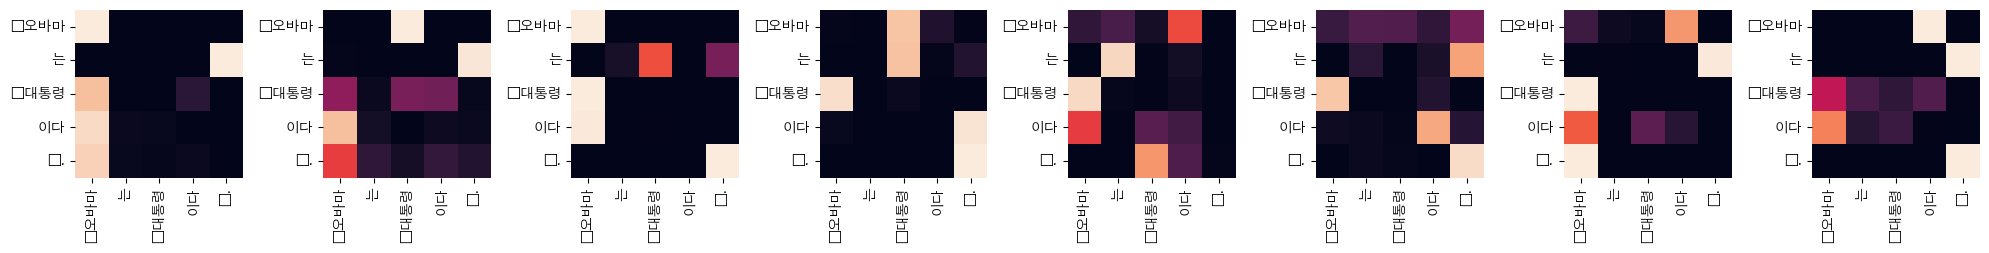

Encoder Layer 2


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pyt

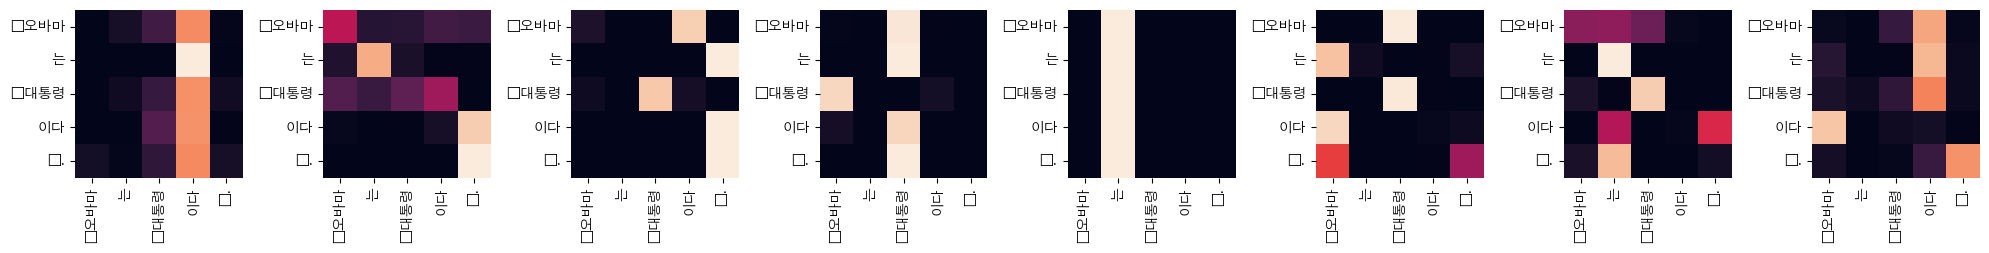

Decoder Self-Attn Layer 1


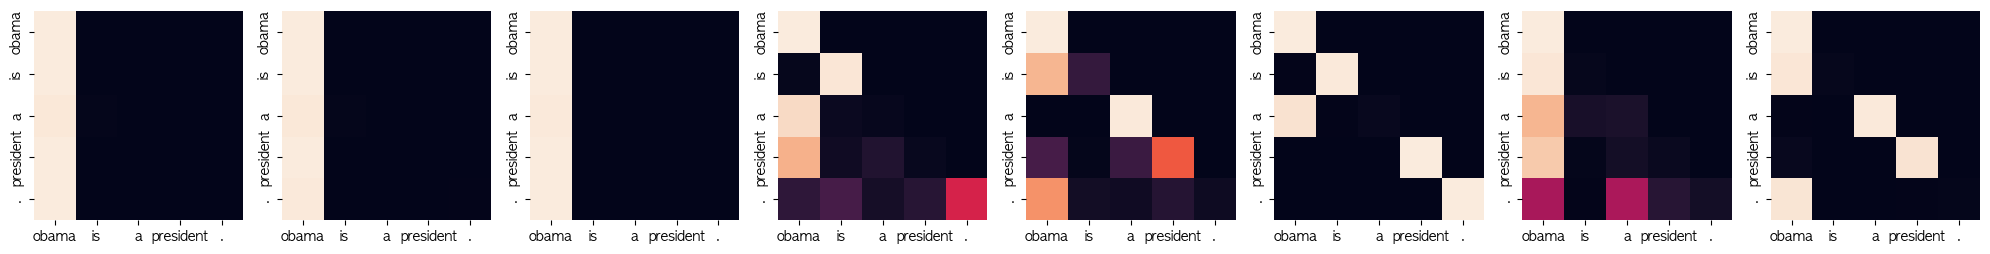

Decoder Cross-Attn Layer 1


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pyt

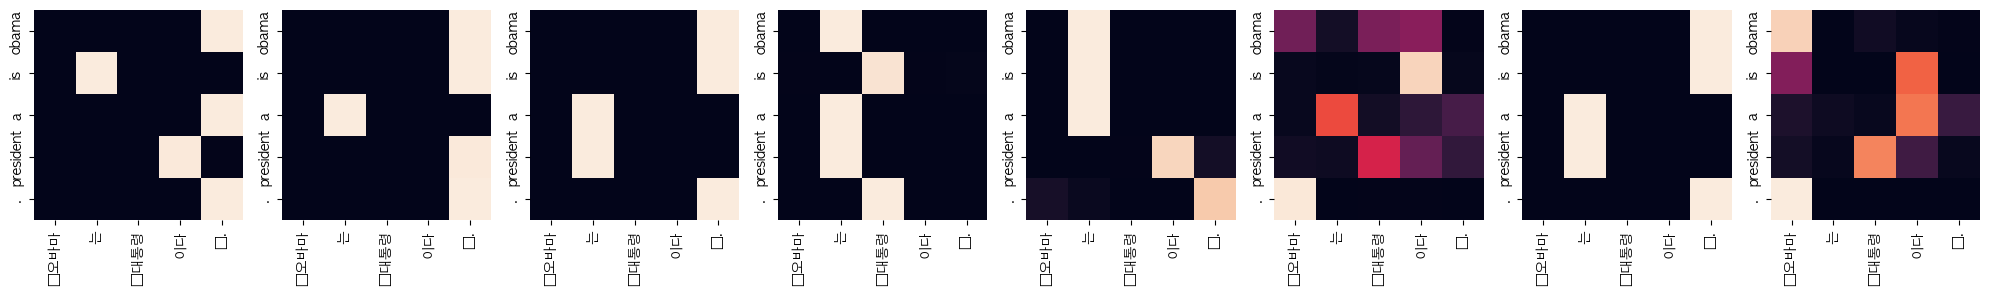

Decoder Self-Attn Layer 2


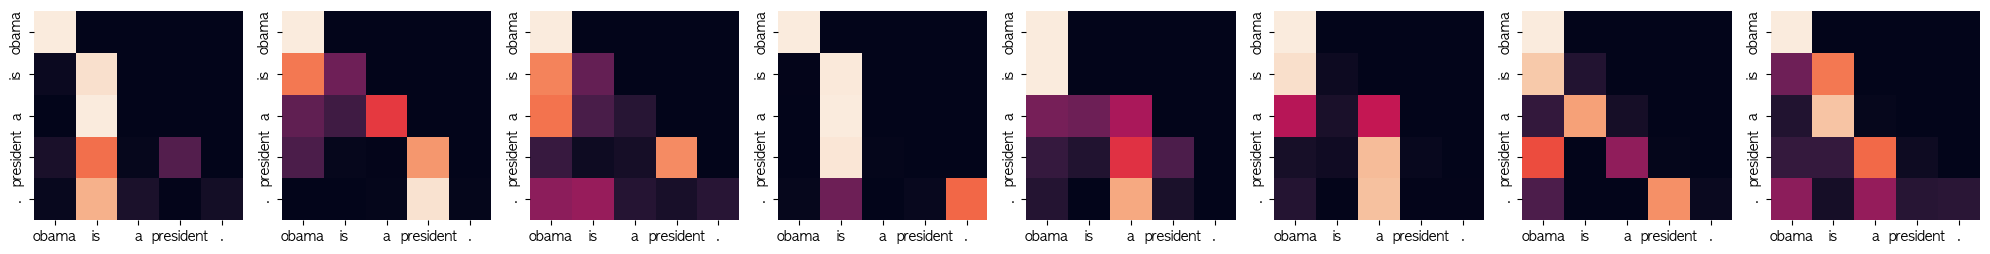

Decoder Cross-Attn Layer 2


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Users/choiseunghyeon/pyt

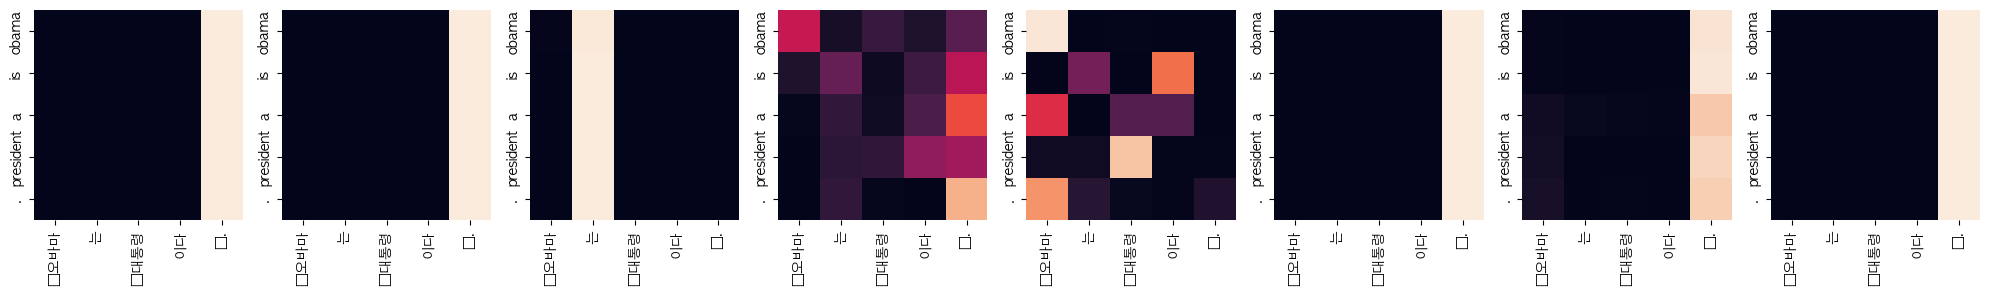

'obama is a president .'

In [9]:
# ================================================================================
# 🎯 [Step 5. 번역 · Attention Map · 프로젝트 제출 출력]
# - best 체크포인트 로드 후 4개 예문 번역
# - 하이퍼파라미터·학습 파라미터 출력 (LMS 제출 형식)
# - 첫 예문 Attention Map 시각화 (루브릭 근거)
# ================================================================================

# 학습 셀을 건너뛰고 이 셀만 실행한 경우를 대비
history = globals().get("history", [])
best_loss = globals().get("best_loss", float("inf"))

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    transformer.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded epoch={ckpt['epoch']}, loss={ckpt['loss']:.4f}")

print("Translations")
for i, q in enumerate(EXAMPLES, 1):
    ans = translate(q, transformer, ko_tokenizer, en_tokenizer)
    print(f"> {i}. {ans}")

print("\nHyperparameters")
print(f"> n_layers: {N_LAYERS}")
print(f"> d_model: {D_MODEL}")
print(f"> n_heads: {N_HEADS}")
print(f"> d_ff: {D_FF}")
print(f"> dropout: {DROPOUT}")
print("\nTraining Parameters")
print(f"> Warmup Steps: {WARMUP_STEPS}")
print(f"> Batch Size: {BATCH_SIZE}")
print(f"> Epoch At: {len(history)}")
print(f"> Best Loss: {best_loss:.4f}")
print(f"> Beam Size: {BEAM_SIZE}")

# 제출 캡쳐용: 첫 예문 Attention Map
translate(EXAMPLES[0], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)


## 회고

### 프로젝트 루브릭 대응

| 루브릭 | 구현 |
|--------|------|
| 데이터 정제·SentencePiece·데이터셋 | Step 1~2 |
| Transformer 학습·한-영 번역 | Step 3~4 |
| 예문 번역 + Attention Map | Step 5 |

### 실행 플로우

```mermaid
flowchart TD
    A[Step0 환경] --> B[Step1 데이터 다운로드]
    B --> C[Step2 정제+SentencePiece]
    C --> D[Step3 Transformer]
    D --> E[Step4 훈련]
    E --> F[Step5 Beam Search 번역+Attention]
```

### 1차 학습 결과 및 문제점

- **Best Loss: 4.6634** (epoch 20, dropout 0.2, greedy decoding)
- 예문 `오바마는 대통령이다.` → `obama is agreed to be a new new poll .`
  - `obama`는 인식했으나 의미 정렬 부족 (`president` 대신 `poll`)
  - `new new`처럼 **토큰 반복**이 심함
- 원인 분석:
  1. **학습 부족** — loss 4.66은 랜덤(~9.9)보다 낫지만 번역 품질로는 아직 높은 편
  2. **Greedy decoding** — 매 스텝 argmax만 사용해 반복·어색한 문장 유발
  3. **뉴스 말뭉치 특성** — 정치·여론조사 표현(`agreed`, `poll`)이 출력에 섞임

### 추가 실험: 하이퍼파라미터·추론 방식 개선

| 항목 | 1차 | 개선 |
|------|-----|------|
| `EPOCHS` | 20 | **40** |
| `DROPOUT` | 0.2 | **0.1** |
| `WARMUP_STEPS` | 4000 | **8000** |
| 추론 | Greedy (`argmax`) | **Beam Search** (`BEAM_SIZE=5`) |

- **epoch 40 + dropout 0.1**: loss를 4.0 이하로 낮춰 의미 정렬 개선 기대
- **warmup 8000**: epoch 증가에 맞춰 Noam 스케줄러 초반 학습 안정화
- **Beam Search**: NLP02 챗봇과 동일하게 상위 5개 후보를 유지하며 탐색 → `new new` 같은 반복 완화
- Attention Map은 beam으로 선택된 최종 시퀀스를 `forward_for_attention()`으로 한 번 더 통과시켜 시각화

### 2차 학습 최종 결과

- **Best Loss: 3.8892** (epoch 40, dropout 0.1, Beam Size 5) — 1차 4.6634 대비 **약 0.77 감소**
- 4개 예문 번역 (Beam Search):

| # | 입력 (한국어) | 출력 (영어) |
|---|--------------|------------|
| 1 | 오바마는 대통령이다. | `obama is a president .` |
| 2 | 시민들은 도시 속에 산다. | `hundreds of thousands of people .` |
| 3 | 커피는 필요 없다. | `it s not very good .` |
| 4 | 일곱 명의 사망자가 발생했다. | `at least people were killed .` |

- **1번 예문**은 의미·문법 모두 그럴듯한 번역으로 개선됨 (`오바마`→`obama`, `대통령`→`president`)
- 2~4번은 아직 의미 정렬이 부족하나, 1차 대비 토큰 반복(`new new`, `best best`)은 크게 줄어듦
- Attention Map에서 `오바마`/`obama`, `대통령`/`president` 간 cross-attention 정렬이 시각적으로 확인됨

### 배운 점

- 한-영 번역은 소스·타겟 언어가 달라 **별도 SentencePiece** 모델이 필요함
- **Attention Map**으로 입력 단어와 출력 단어의 정렬 관계를 시각적으로 확인 가능
- **loss 수치만으로는 번역 품질을 판단하기 어렵고**, epoch·decoding 방식(greedy vs beam)을 함께 봐야 함
- **하이퍼파라미터 튜닝 + Beam Search** 조합이 실제 번역 품질 개선에 효과적임을 직접 확인함
- Mac MPS 환경에서는 `tqdm.notebook` 대신 `tqdm`, attention mask는 `masked_fill` 대신 `scores + (mask * -1e9)` 사용이 안정적

### 아쉬운 점

- 전체 코퍼스 40 epoch 학습에 Mac MPS 기준 **3~4시간** 소요
- 2-layer 소형 모델 한계로, 뉴스 말뭉치에 없는 표현은 여전히 어색할 수 있음
- 검증셋 분리·Early Stopping은 NLP02처럼 도입하지 않아, train loss 기준 best checkpoint를 사용함
